In [61]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import math

In [62]:
df = pd.read_csv("final_dataset_hourly.csv", index_col=0, parse_dates=True)

# 填充 UVI > 20 为 NaN
df.loc[df["UVI"] > 20, "UVI"] = np.nan
# 线性插值补全
df = df.interpolate(method="linear")
# 夜间缺失的可填 0
df["UVI"].fillna(0, inplace=True)

# 周期特征编码
df['hour_sin'] = np.sin(2*np.pi*df.index.hour/24)
df['hour_cos'] = np.cos(2*np.pi*df.index.hour/24)
df['day_year_sin'] = np.sin(2*np.pi*df.index.dayofyear/365)
df['day_year_cos'] = np.cos(2*np.pi*df.index.dayofyear/365)

feature_cols = ['temp','rainfall','windspd','windspd_max','wind_d',
                'GHI','DNI','DHI','UVA','ClearSkyGHI','CSI','UVI',
                'hour_sin','hour_cos','day_year_sin','day_year_cos']
target_col = 'UVI'

# 数据集切分
train_df = df.loc['2020-01-01':'2021-06-30']
val_df   = df.loc['2021-07-01':'2021-09-30']
test_df  = df.loc['2021-10-01':'2021-12-29']

C:\Users\apple\AppData\Local\Temp\ipykernel_5624\2944346577.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["UVI"].fillna(0, inplace=True)


In [63]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

train_x = x_scaler.fit_transform(train_df[feature_cols])
val_x   = x_scaler.transform(val_df[feature_cols])
test_x  = x_scaler.transform(test_df[feature_cols])

train_y = y_scaler.fit_transform(train_df[[target_col]])
val_y   = y_scaler.transform(val_df[[target_col]])
test_y  = y_scaler.transform(test_df[[target_col]])

In [64]:
class WeatherTimeSeriesDataset(Dataset):
    def __init__(self, data_matrix, target_matrix, seq_len=96, pred_len=24):
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.valid_length = len(data_matrix) - seq_len - pred_len + 1
        self.x = torch.FloatTensor(data_matrix)
        self.y = torch.FloatTensor(target_matrix)

    def __len__(self):
        return self.valid_length

    def __getitem__(self, idx):
        seq_x = self.x[idx:idx+self.seq_len]
        seq_y = self.y[idx+self.seq_len: idx+self.seq_len+self.pred_len, 0]
        return seq_x, seq_y

train_dataset = WeatherTimeSeriesDataset(train_x, train_y)
val_dataset   = WeatherTimeSeriesDataset(val_x, val_y)
test_dataset  = WeatherTimeSeriesDataset(test_x, test_y)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [65]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [66]:
print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

407
66
64


In [67]:
x, y = next(iter(train_loader))

print("x shape =", x.shape)
print("y shape =", y.shape)

x shape = torch.Size([32, 96, 16])
y shape = torch.Size([32, 24])


In [68]:
__all__ = ['Transpose', 'get_activation_fn', 'moving_avg', 'series_decomp', 'PositionalEncoding', 'SinCosPosEncoding', 'Coord2dPosEncoding', 'Coord1dPosEncoding', 'positional_encoding']           

import torch
from torch import nn
import math

class Transpose(nn.Module):
    def __init__(self, *dims, contiguous=False): 
        super().__init__()
        self.dims, self.contiguous = dims, contiguous
    def forward(self, x):
        if self.contiguous: return x.transpose(*self.dims).contiguous()
        else: return x.transpose(*self.dims)

    
def get_activation_fn(activation):
    if callable(activation): return activation()
    elif activation.lower() == "relu": return nn.ReLU()
    elif activation.lower() == "gelu": return nn.GELU()
    raise ValueError(f'{activation} is not available. You can use "relu", "gelu", or a callable') 
    
    
# decomposition

class moving_avg(nn.Module):
    """
    Moving average block to highlight the trend of time series
    """
    def __init__(self, kernel_size, stride):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # padding on the both ends of time series
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        x = x.permute(0, 2, 1)
        return x


class series_decomp(nn.Module):
    """
    Series decomposition block
    """
    def __init__(self, kernel_size):
        super(series_decomp, self).__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)

    def forward(self, x):
        moving_mean = self.moving_avg(x)
        res = x - moving_mean
        return res, moving_mean
    
    
    
# pos_encoding

def PositionalEncoding(q_len, d_model, normalize=True):
    pe = torch.zeros(q_len, d_model)
    position = torch.arange(0, q_len).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    if normalize:
        pe = pe - pe.mean()
        pe = pe / (pe.std() * 10)
    return pe

SinCosPosEncoding = PositionalEncoding

def Coord2dPosEncoding(q_len, d_model, exponential=False, normalize=True, eps=1e-3, verbose=False):
    x = .5 if exponential else 1
    i = 0
    for i in range(100):
        cpe = 2 * (torch.linspace(0, 1, q_len).reshape(-1, 1) ** x) * (torch.linspace(0, 1, d_model).reshape(1, -1) ** x) - 1
        pv(f'{i:4.0f}  {x:5.3f}  {cpe.mean():+6.3f}', verbose)
        if abs(cpe.mean()) <= eps: break
        elif cpe.mean() > eps: x += .001
        else: x -= .001
        i += 1
    if normalize:
        cpe = cpe - cpe.mean()
        cpe = cpe / (cpe.std() * 10)
    return cpe

def Coord1dPosEncoding(q_len, exponential=False, normalize=True):
    cpe = (2 * (torch.linspace(0, 1, q_len).reshape(-1, 1)**(.5 if exponential else 1)) - 1)
    if normalize:
        cpe = cpe - cpe.mean()
        cpe = cpe / (cpe.std() * 10)
    return cpe

def positional_encoding(pe, learn_pe, q_len, d_model):
    # Positional encoding
    if pe == None:
        W_pos = torch.empty((q_len, d_model)) # pe = None and learn_pe = False can be used to measure impact of pe
        nn.init.uniform_(W_pos, -0.02, 0.02)
        learn_pe = False
    elif pe == 'zero':
        W_pos = torch.empty((q_len, 1))
        nn.init.uniform_(W_pos, -0.02, 0.02)
    elif pe == 'zeros':
        W_pos = torch.empty((q_len, d_model))
        nn.init.uniform_(W_pos, -0.02, 0.02)
    elif pe == 'normal' or pe == 'gauss':
        W_pos = torch.zeros((q_len, 1))
        torch.nn.init.normal_(W_pos, mean=0.0, std=0.1)
    elif pe == 'uniform':
        W_pos = torch.zeros((q_len, 1))
        nn.init.uniform_(W_pos, a=0.0, b=0.1)
    elif pe == 'lin1d': W_pos = Coord1dPosEncoding(q_len, exponential=False, normalize=True)
    elif pe == 'exp1d': W_pos = Coord1dPosEncoding(q_len, exponential=True, normalize=True)
    elif pe == 'lin2d': W_pos = Coord2dPosEncoding(q_len, d_model, exponential=False, normalize=True)
    elif pe == 'exp2d': W_pos = Coord2dPosEncoding(q_len, d_model, exponential=True, normalize=True)
    elif pe == 'sincos': W_pos = PositionalEncoding(q_len, d_model, normalize=True)
    else: raise ValueError(f"{pe} is not a valid pe (positional encoder. Available types: 'gauss'=='normal', \
        'zeros', 'zero', uniform', 'lin1d', 'exp1d', 'lin2d', 'exp2d', 'sincos', None.)")
    return nn.Parameter(W_pos, requires_grad=learn_pe)

In [69]:
import torch
import torch.nn as nn

class RevIN(nn.Module):
    def __init__(self, num_features: int, eps=1e-5, affine=True, subtract_last=False):
        """
        :param num_features: the number of features or channels
        :param eps: a value added for numerical stability
        :param affine: if True, RevIN has learnable affine parameters
        """
        super(RevIN, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        self.subtract_last = subtract_last
        if self.affine:
            self._init_params()

    def forward(self, x, mode:str):
        if mode == 'norm':
            self._get_statistics(x)
            x = self._normalize(x)
        elif mode == 'denorm':
            x = self._denormalize(x)
        else: raise NotImplementedError
        return x

    def _init_params(self):
        # initialize RevIN params: (C,)
        self.affine_weight = nn.Parameter(torch.ones(self.num_features))
        self.affine_bias = nn.Parameter(torch.zeros(self.num_features))

    def _get_statistics(self, x):
        dim2reduce = tuple(range(1, x.ndim-1))
        if self.subtract_last:
            self.last = x[:,-1,:].unsqueeze(1)
        else:
            self.mean = torch.mean(x, dim=dim2reduce, keepdim=True).detach()
        self.stdev = torch.sqrt(torch.var(x, dim=dim2reduce, keepdim=True, unbiased=False) + self.eps).detach()

    def _normalize(self, x):
        if self.subtract_last:
            x = x - self.last
        else:
            x = x - self.mean
        x = x / self.stdev
        if self.affine:
            x = x * self.affine_weight
            x = x + self.affine_bias
        return x

    def _denormalize(self, x):
        if self.affine:
            x = x - self.affine_bias
            x = x / (self.affine_weight + self.eps*self.eps)
        x = x * self.stdev
        if self.subtract_last:
            x = x + self.last
        else:
            x = x + self.mean
        return x

In [70]:
__all__ = ['PatchTST_backbone']

# Cell
from typing import Callable, Optional
import torch
from torch import nn
from torch import Tensor
import torch.nn.functional as F
import numpy as np

# Cell
class PatchTST_backbone(nn.Module):
    def __init__(self, c_in:int, context_window:int, target_window:int, patch_len:int, stride:int, max_seq_len:Optional[int]=1024, 
                 n_layers:int=3, d_model=128, n_heads=16, d_k:Optional[int]=None, d_v:Optional[int]=None,
                 d_ff:int=256, norm:str='BatchNorm', attn_dropout:float=0., dropout:float=0., act:str="gelu", key_padding_mask:bool='auto',
                 padding_var:Optional[int]=None, attn_mask:Optional[Tensor]=None, res_attention:bool=True, pre_norm:bool=False, store_attn:bool=False,
                 pe:str='zeros', learn_pe:bool=True, fc_dropout:float=0., head_dropout = 0, padding_patch = None,
                 pretrain_head:bool=False, head_type = 'flatten', individual = False, revin = True, affine = True, subtract_last = False,
                 verbose:bool=False, **kwargs):
        
        super().__init__()
        
        # RevIn
        self.revin = revin
        if self.revin: self.revin_layer = RevIN(c_in, affine=affine, subtract_last=subtract_last)
        
        # Patching
        self.patch_len = patch_len
        self.stride = stride
        self.padding_patch = padding_patch
        patch_num = int((context_window - patch_len)/stride + 1)
        if padding_patch == 'end': # can be modified to general case
            self.padding_patch_layer = nn.ReplicationPad1d((0, stride)) 
            patch_num += 1
        
        # Backbone 
        self.backbone = TSTiEncoder(c_in, patch_num=patch_num, patch_len=patch_len, max_seq_len=max_seq_len,
                                n_layers=n_layers, d_model=d_model, n_heads=n_heads, d_k=d_k, d_v=d_v, d_ff=d_ff,
                                attn_dropout=attn_dropout, dropout=dropout, act=act, key_padding_mask=key_padding_mask, padding_var=padding_var,
                                attn_mask=attn_mask, res_attention=res_attention, pre_norm=pre_norm, store_attn=store_attn,
                                pe=pe, learn_pe=learn_pe, verbose=verbose, **kwargs)

        # Head
        self.head_nf = d_model * patch_num
        self.n_vars = c_in
        self.pretrain_head = pretrain_head
        self.head_type = head_type
        self.individual = individual

        if self.pretrain_head: 
            self.head = self.create_pretrain_head(self.head_nf, c_in, fc_dropout) # custom head passed as a partial func with all its kwargs
        elif head_type == 'flatten': 
            self.head = Flatten_Head(self.individual, self.n_vars, self.head_nf, target_window, head_dropout=head_dropout)
        
    
    def forward(self, z):                                                                   # z: [bs x nvars x seq_len]
        # norm
        if self.revin: 
            z = z.permute(0,2,1)
            z = self.revin_layer(z, 'norm')
            z = z.permute(0,2,1)
            
        # do patching
        if self.padding_patch == 'end':
            z = self.padding_patch_layer(z)
        z = z.unfold(dimension=-1, size=self.patch_len, step=self.stride)                   # z: [bs x nvars x patch_num x patch_len]
        z = z.permute(0,1,3,2)                                                              # z: [bs x nvars x patch_len x patch_num]
        
        # model
        z = self.backbone(z)                                                                # z: [bs x nvars x d_model x patch_num]
        z = self.head(z)                                                                    # z: [bs x nvars x target_window] 
        
        # denorm
        if self.revin: 
            z = z.permute(0,2,1)
            z = self.revin_layer(z, 'denorm')
            z = z.permute(0,2,1)
        return z
    
    def create_pretrain_head(self, head_nf, vars, dropout):
        return nn.Sequential(nn.Dropout(dropout),
                    nn.Conv1d(head_nf, vars, 1)
                    )


class Flatten_Head(nn.Module):
    def __init__(self, individual, n_vars, nf, target_window, head_dropout=0):
        super().__init__()
        
        self.individual = individual
        self.n_vars = n_vars
        
        if self.individual:
            self.linears = nn.ModuleList()
            self.dropouts = nn.ModuleList()
            self.flattens = nn.ModuleList()
            for i in range(self.n_vars):
                self.flattens.append(nn.Flatten(start_dim=-2))
                self.linears.append(nn.Linear(nf, target_window))
                self.dropouts.append(nn.Dropout(head_dropout))
        else:
            self.flatten = nn.Flatten(start_dim=-2)
            self.linear = nn.Linear(nf, target_window)
            self.dropout = nn.Dropout(head_dropout)
            
    def forward(self, x):                                 # x: [bs x nvars x d_model x patch_num]
        if self.individual:
            x_out = []
            for i in range(self.n_vars):
                z = self.flattens[i](x[:,i,:,:])          # z: [bs x d_model * patch_num]
                z = self.linears[i](z)                    # z: [bs x target_window]
                z = self.dropouts[i](z)
                x_out.append(z)
            x = torch.stack(x_out, dim=1)                 # x: [bs x nvars x target_window]
        else:
            x = self.flatten(x)
            x = self.linear(x)
            x = self.dropout(x)
        return x
        
        
    
    
class TSTiEncoder(nn.Module):  #i means channel-independent
    def __init__(self, c_in, patch_num, patch_len, max_seq_len=1024,
                 n_layers=3, d_model=128, n_heads=16, d_k=None, d_v=None,
                 d_ff=256, norm='BatchNorm', attn_dropout=0., dropout=0., act="gelu", store_attn=False,
                 key_padding_mask='auto', padding_var=None, attn_mask=None, res_attention=True, pre_norm=False,
                 pe='zeros', learn_pe=True, verbose=False, **kwargs):
        
        
        super().__init__()
        
        self.patch_num = patch_num
        self.patch_len = patch_len
        
        # Input encoding
        q_len = patch_num
        self.W_P = nn.Linear(patch_len, d_model)        # Eq 1: projection of feature vectors onto a d-dim vector space
        self.seq_len = q_len

        # Positional encoding
        self.W_pos = positional_encoding(pe, learn_pe, q_len, d_model)

        # Residual dropout
        self.dropout = nn.Dropout(dropout)

        # Encoder
        self.encoder = TSTEncoder(q_len, d_model, n_heads, d_k=d_k, d_v=d_v, d_ff=d_ff, norm=norm, attn_dropout=attn_dropout, dropout=dropout,
                                   pre_norm=pre_norm, activation=act, res_attention=res_attention, n_layers=n_layers, store_attn=store_attn)

        
    def forward(self, x) -> Tensor:                                              # x: [bs x nvars x patch_len x patch_num]
        
        n_vars = x.shape[1]
        # Input encoding
        x = x.permute(0,1,3,2)                                                   # x: [bs x nvars x patch_num x patch_len]
        x = self.W_P(x)                                                          # x: [bs x nvars x patch_num x d_model]

        u = torch.reshape(x, (x.shape[0]*x.shape[1],x.shape[2],x.shape[3]))      # u: [bs * nvars x patch_num x d_model]
        u = self.dropout(u + self.W_pos)                                         # u: [bs * nvars x patch_num x d_model]

        # Encoder
        z = self.encoder(u)                                                      # z: [bs * nvars x patch_num x d_model]
        z = torch.reshape(z, (-1,n_vars,z.shape[-2],z.shape[-1]))                # z: [bs x nvars x patch_num x d_model]
        z = z.permute(0,1,3,2)                                                   # z: [bs x nvars x d_model x patch_num]
        
        return z    
            
            
    
# Cell
class TSTEncoder(nn.Module):
    def __init__(self, q_len, d_model, n_heads, d_k=None, d_v=None, d_ff=None, 
                        norm='BatchNorm', attn_dropout=0., dropout=0., activation='gelu',
                        res_attention=False, n_layers=1, pre_norm=False, store_attn=False):
        super().__init__()

        self.layers = nn.ModuleList([TSTEncoderLayer(q_len, d_model, n_heads=n_heads, d_k=d_k, d_v=d_v, d_ff=d_ff, norm=norm,
                                                      attn_dropout=attn_dropout, dropout=dropout,
                                                      activation=activation, res_attention=res_attention,
                                                      pre_norm=pre_norm, store_attn=store_attn) for i in range(n_layers)])
        self.res_attention = res_attention

    def forward(self, src:Tensor, key_padding_mask:Optional[Tensor]=None, attn_mask:Optional[Tensor]=None):
        output = src
        scores = None
        if self.res_attention:
            for mod in self.layers: output, scores = mod(output, prev=scores, key_padding_mask=key_padding_mask, attn_mask=attn_mask)
            return output
        else:
            for mod in self.layers: output = mod(output, key_padding_mask=key_padding_mask, attn_mask=attn_mask)
            return output



class TSTEncoderLayer(nn.Module):
    def __init__(self, q_len, d_model, n_heads, d_k=None, d_v=None, d_ff=256, store_attn=False,
                 norm='BatchNorm', attn_dropout=0, dropout=0., bias=True, activation="gelu", res_attention=False, pre_norm=False):
        super().__init__()
        assert not d_model%n_heads, f"d_model ({d_model}) must be divisible by n_heads ({n_heads})"
        d_k = d_model // n_heads if d_k is None else d_k
        d_v = d_model // n_heads if d_v is None else d_v

        # Multi-Head attention
        self.res_attention = res_attention
        self.self_attn = _MultiheadAttention(d_model, n_heads, d_k, d_v, attn_dropout=attn_dropout, proj_dropout=dropout, res_attention=res_attention)

        # Add & Norm
        self.dropout_attn = nn.Dropout(dropout)
        if "batch" in norm.lower():
            self.norm_attn = nn.Sequential(Transpose(1,2), nn.BatchNorm1d(d_model), Transpose(1,2))
        else:
            self.norm_attn = nn.LayerNorm(d_model)

        # Position-wise Feed-Forward
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff, bias=bias),
                                get_activation_fn(activation),
                                nn.Dropout(dropout),
                                nn.Linear(d_ff, d_model, bias=bias))

        # Add & Norm
        self.dropout_ffn = nn.Dropout(dropout)
        if "batch" in norm.lower():
            self.norm_ffn = nn.Sequential(Transpose(1,2), nn.BatchNorm1d(d_model), Transpose(1,2))
        else:
            self.norm_ffn = nn.LayerNorm(d_model)

        self.pre_norm = pre_norm
        self.store_attn = store_attn


    def forward(self, src:Tensor, prev:Optional[Tensor]=None, key_padding_mask:Optional[Tensor]=None, attn_mask:Optional[Tensor]=None) -> Tensor:

        # Multi-Head attention sublayer
        if self.pre_norm:
            src = self.norm_attn(src)
        ## Multi-Head attention
        if self.res_attention:
            src2, attn, scores = self.self_attn(src, src, src, prev, key_padding_mask=key_padding_mask, attn_mask=attn_mask)
        else:
            src2, attn = self.self_attn(src, src, src, key_padding_mask=key_padding_mask, attn_mask=attn_mask)
        if self.store_attn:
            self.attn = attn
        ## Add & Norm
        src = src + self.dropout_attn(src2) # Add: residual connection with residual dropout
        if not self.pre_norm:
            src = self.norm_attn(src)

        # Feed-forward sublayer
        if self.pre_norm:
            src = self.norm_ffn(src)
        ## Position-wise Feed-Forward
        src2 = self.ff(src)
        ## Add & Norm
        src = src + self.dropout_ffn(src2) # Add: residual connection with residual dropout
        if not self.pre_norm:
            src = self.norm_ffn(src)

        if self.res_attention:
            return src, scores
        else:
            return src




class _MultiheadAttention(nn.Module):
    def __init__(self, d_model, n_heads, d_k=None, d_v=None, res_attention=False, attn_dropout=0., proj_dropout=0., qkv_bias=True, lsa=False):
        """Multi Head Attention Layer
        Input shape:
            Q:       [batch_size (bs) x max_q_len x d_model]
            K, V:    [batch_size (bs) x q_len x d_model]
            mask:    [q_len x q_len]
        """
        super().__init__()
        d_k = d_model // n_heads if d_k is None else d_k
        d_v = d_model // n_heads if d_v is None else d_v

        self.n_heads, self.d_k, self.d_v = n_heads, d_k, d_v

        self.W_Q = nn.Linear(d_model, d_k * n_heads, bias=qkv_bias)
        self.W_K = nn.Linear(d_model, d_k * n_heads, bias=qkv_bias)
        self.W_V = nn.Linear(d_model, d_v * n_heads, bias=qkv_bias)

        # Scaled Dot-Product Attention (multiple heads)
        self.res_attention = res_attention
        self.sdp_attn = _ScaledDotProductAttention(d_model, n_heads, attn_dropout=attn_dropout, res_attention=self.res_attention, lsa=lsa)

        # Poject output
        self.to_out = nn.Sequential(nn.Linear(n_heads * d_v, d_model), nn.Dropout(proj_dropout))


    def forward(self, Q:Tensor, K:Optional[Tensor]=None, V:Optional[Tensor]=None, prev:Optional[Tensor]=None,
                key_padding_mask:Optional[Tensor]=None, attn_mask:Optional[Tensor]=None):

        bs = Q.size(0)
        if K is None: K = Q
        if V is None: V = Q

        # Linear (+ split in multiple heads)
        q_s = self.W_Q(Q).view(bs, -1, self.n_heads, self.d_k).transpose(1,2)       # q_s    : [bs x n_heads x max_q_len x d_k]
        k_s = self.W_K(K).view(bs, -1, self.n_heads, self.d_k).permute(0,2,3,1)     # k_s    : [bs x n_heads x d_k x q_len] - transpose(1,2) + transpose(2,3)
        v_s = self.W_V(V).view(bs, -1, self.n_heads, self.d_v).transpose(1,2)       # v_s    : [bs x n_heads x q_len x d_v]

        # Apply Scaled Dot-Product Attention (multiple heads)
        if self.res_attention:
            output, attn_weights, attn_scores = self.sdp_attn(q_s, k_s, v_s, prev=prev, key_padding_mask=key_padding_mask, attn_mask=attn_mask)
        else:
            output, attn_weights = self.sdp_attn(q_s, k_s, v_s, key_padding_mask=key_padding_mask, attn_mask=attn_mask)
        # output: [bs x n_heads x q_len x d_v], attn: [bs x n_heads x q_len x q_len], scores: [bs x n_heads x max_q_len x q_len]

        # back to the original inputs dimensions
        output = output.transpose(1, 2).contiguous().view(bs, -1, self.n_heads * self.d_v) # output: [bs x q_len x n_heads * d_v]
        output = self.to_out(output)

        if self.res_attention: return output, attn_weights, attn_scores
        else: return output, attn_weights


class _ScaledDotProductAttention(nn.Module):
    r"""Scaled Dot-Product Attention module (Attention is all you need by Vaswani et al., 2017) with optional residual attention from previous layer
    (Realformer: Transformer likes residual attention by He et al, 2020) and locality self sttention (Vision Transformer for Small-Size Datasets
    by Lee et al, 2021)"""

    def __init__(self, d_model, n_heads, attn_dropout=0., res_attention=False, lsa=False):
        super().__init__()
        self.attn_dropout = nn.Dropout(attn_dropout)
        self.res_attention = res_attention
        head_dim = d_model // n_heads
        self.scale = nn.Parameter(torch.tensor(head_dim ** -0.5), requires_grad=lsa)
        self.lsa = lsa

    def forward(self, q:Tensor, k:Tensor, v:Tensor, prev:Optional[Tensor]=None, key_padding_mask:Optional[Tensor]=None, attn_mask:Optional[Tensor]=None):
        '''
        Input shape:
            q               : [bs x n_heads x max_q_len x d_k]
            k               : [bs x n_heads x d_k x seq_len]
            v               : [bs x n_heads x seq_len x d_v]
            prev            : [bs x n_heads x q_len x seq_len]
            key_padding_mask: [bs x seq_len]
            attn_mask       : [1 x seq_len x seq_len]
        Output shape:
            output:  [bs x n_heads x q_len x d_v]
            attn   : [bs x n_heads x q_len x seq_len]
            scores : [bs x n_heads x q_len x seq_len]
        '''

        # Scaled MatMul (q, k) - similarity scores for all pairs of positions in an input sequence
        attn_scores = torch.matmul(q, k) * self.scale      # attn_scores : [bs x n_heads x max_q_len x q_len]

        # Add pre-softmax attention scores from the previous layer (optional)
        if prev is not None: attn_scores = attn_scores + prev

        # Attention mask (optional)
        if attn_mask is not None:                                     # attn_mask with shape [q_len x seq_len] - only used when q_len == seq_len
            if attn_mask.dtype == torch.bool:
                attn_scores.masked_fill_(attn_mask, -np.inf)
            else:
                attn_scores += attn_mask

        # Key padding mask (optional)
        if key_padding_mask is not None:                              # mask with shape [bs x q_len] (only when max_w_len == q_len)
            attn_scores.masked_fill_(key_padding_mask.unsqueeze(1).unsqueeze(2), -np.inf)

        # normalize the attention weights
        attn_weights = F.softmax(attn_scores, dim=-1)                 # attn_weights   : [bs x n_heads x max_q_len x q_len]
        attn_weights = self.attn_dropout(attn_weights)

        # compute the new values given the attention weights
        output = torch.matmul(attn_weights, v)                        # output: [bs x n_heads x max_q_len x d_v]

        if self.res_attention: return output, attn_weights, attn_scores
        else: return output, attn_weights


In [71]:
__all__ = ['PatchTST']

# Cell
from typing import Callable, Optional
import torch
from torch import nn
from torch import Tensor
import torch.nn.functional as F
import numpy as np


class Model(nn.Module):
    def __init__(self, configs, max_seq_len:Optional[int]=1024, d_k:Optional[int]=None, d_v:Optional[int]=None, norm:str='BatchNorm', attn_dropout:float=0., 
                 act:str="gelu", key_padding_mask:bool='auto',padding_var:Optional[int]=None, attn_mask:Optional[Tensor]=None, res_attention:bool=True, 
                 pre_norm:bool=False, store_attn:bool=False, pe:str='zeros', learn_pe:bool=True, pretrain_head:bool=False, head_type = 'flatten', verbose:bool=False, **kwargs):
        
        super().__init__()
        
        # load parameters
        c_in = configs.enc_in
        context_window = configs.seq_len
        target_window = configs.pred_len
        
        n_layers = configs.e_layers
        n_heads = configs.n_heads
        d_model = configs.d_model
        d_ff = configs.d_ff
        dropout = configs.dropout
        fc_dropout = configs.fc_dropout
        head_dropout = configs.head_dropout
        
        individual = configs.individual
    
        patch_len = configs.patch_len
        stride = configs.stride
        padding_patch = configs.padding_patch
        
        revin = configs.revin
        affine = configs.affine
        subtract_last = configs.subtract_last
        
        decomposition = configs.decomposition
        kernel_size = configs.kernel_size
        
        
        # model
        self.decomposition = decomposition
        if self.decomposition:
            self.decomp_module = series_decomp(kernel_size)
            self.model_trend = PatchTST_backbone(c_in=c_in, context_window = context_window, target_window=target_window, patch_len=patch_len, stride=stride, 
                                  max_seq_len=max_seq_len, n_layers=n_layers, d_model=d_model,
                                  n_heads=n_heads, d_k=d_k, d_v=d_v, d_ff=d_ff, norm=norm, attn_dropout=attn_dropout,
                                  dropout=dropout, act=act, key_padding_mask=key_padding_mask, padding_var=padding_var, 
                                  attn_mask=attn_mask, res_attention=res_attention, pre_norm=pre_norm, store_attn=store_attn,
                                  pe=pe, learn_pe=learn_pe, fc_dropout=fc_dropout, head_dropout=head_dropout, padding_patch = padding_patch,
                                  pretrain_head=pretrain_head, head_type=head_type, individual=individual, revin=revin, affine=affine,
                                  subtract_last=subtract_last, verbose=verbose, **kwargs)
            self.model_res = PatchTST_backbone(c_in=c_in, context_window = context_window, target_window=target_window, patch_len=patch_len, stride=stride, 
                                  max_seq_len=max_seq_len, n_layers=n_layers, d_model=d_model,
                                  n_heads=n_heads, d_k=d_k, d_v=d_v, d_ff=d_ff, norm=norm, attn_dropout=attn_dropout,
                                  dropout=dropout, act=act, key_padding_mask=key_padding_mask, padding_var=padding_var, 
                                  attn_mask=attn_mask, res_attention=res_attention, pre_norm=pre_norm, store_attn=store_attn,
                                  pe=pe, learn_pe=learn_pe, fc_dropout=fc_dropout, head_dropout=head_dropout, padding_patch = padding_patch,
                                  pretrain_head=pretrain_head, head_type=head_type, individual=individual, revin=revin, affine=affine,
                                  subtract_last=subtract_last, verbose=verbose, **kwargs)
        else:
            self.model = PatchTST_backbone(c_in=c_in, context_window = context_window, target_window=target_window, patch_len=patch_len, stride=stride, 
                                  max_seq_len=max_seq_len, n_layers=n_layers, d_model=d_model,
                                  n_heads=n_heads, d_k=d_k, d_v=d_v, d_ff=d_ff, norm=norm, attn_dropout=attn_dropout,
                                  dropout=dropout, act=act, key_padding_mask=key_padding_mask, padding_var=padding_var, 
                                  attn_mask=attn_mask, res_attention=res_attention, pre_norm=pre_norm, store_attn=store_attn,
                                  pe=pe, learn_pe=learn_pe, fc_dropout=fc_dropout, head_dropout=head_dropout, padding_patch = padding_patch,
                                  pretrain_head=pretrain_head, head_type=head_type, individual=individual, revin=revin, affine=affine,
                                  subtract_last=subtract_last, verbose=verbose, **kwargs)
    
    
    def forward(self, x):           # x: [Batch, Input length, Channel]
        if self.decomposition:
            res_init, trend_init = self.decomp_module(x)
            res_init, trend_init = res_init.permute(0,2,1), trend_init.permute(0,2,1)  # x: [Batch, Channel, Input length]
            res = self.model_res(res_init)
            trend = self.model_trend(trend_init)
            x = res + trend
            x = x.permute(0,2,1)    # x: [Batch, Input length, Channel]
        else:
            x = x.permute(0,2,1)    # x: [Batch, Channel, Input length]
            x = self.model(x)
            x = x.permute(0,2,1)    # x: [Batch, Input length, Channel]
        return x

Epoch 01 | Train Loss=0.1301 | Val Loss=0.1552
Epoch 02 | Train Loss=0.1217 | Val Loss=0.1616
Epoch 03 | Train Loss=0.1214 | Val Loss=0.1562
Epoch 04 | Train Loss=0.1192 | Val Loss=0.1583
Epoch 05 | Train Loss=0.1189 | Val Loss=0.1572
Epoch 06 | Train Loss=0.1187 | Val Loss=0.1569
Early stopping (best val=0.1552)
PatchTST Test (Original Scale)
MAE  = 0.3928
RMSE = 0.7646
R²   = 0.8088


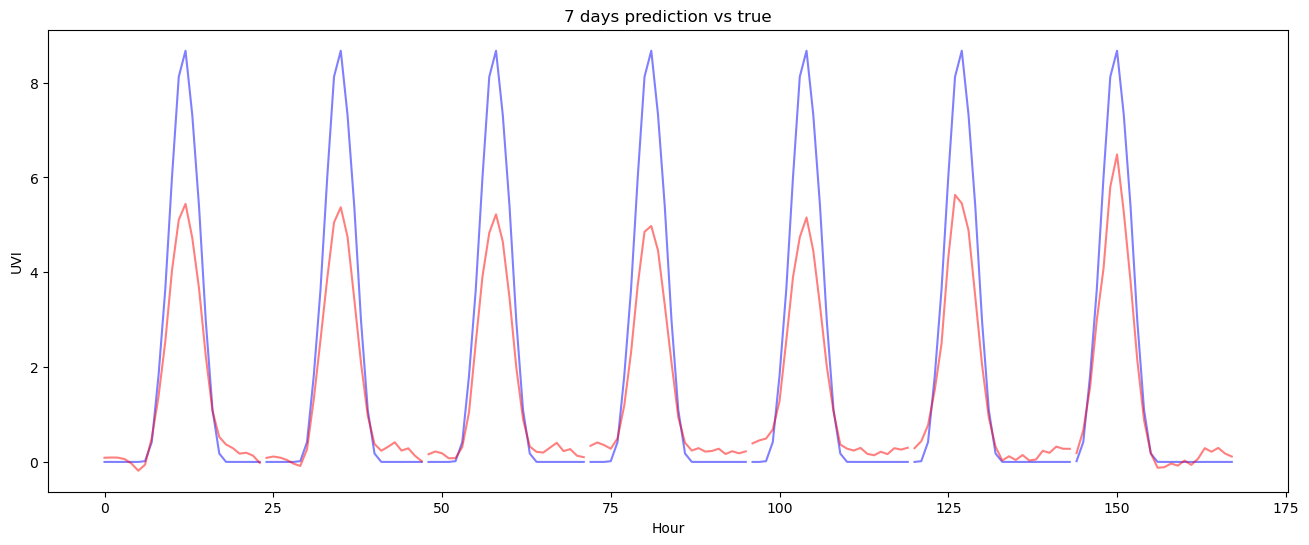

In [75]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# 配置
# ----------------------------
class Config:
    pass

cfg = Config()

cfg.enc_in = 16
cfg.seq_len = 96
cfg.pred_len = 24

cfg.e_layers = 3
cfg.n_heads = 8
cfg.d_model = 128
cfg.d_ff = 256
cfg.dropout = 0.1
cfg.fc_dropout = 0.1
cfg.head_dropout = 0.1
cfg.individual = False

cfg.patch_len = 16
cfg.stride = 8
cfg.padding_patch = "end"

cfg.revin = True
cfg.affine = True
cfg.subtract_last = False
cfg.decomposition = False
cfg.kernel_size = 25

UVI_idx = 9  # 'UVI' 列索引

device = "cuda" if torch.cuda.is_available() else "cpu"

# ----------------------------
# 单目标 UVI PatchTST 封装
# ----------------------------
class PatchTST_UVI(nn.Module):
    def __init__(self, backbone, target_idx=UVI_idx):
        super().__init__()
        self.backbone = backbone
        self.target_idx = target_idx

    def forward(self, x):
        out = self.backbone(x)
        return out[:, :, self.target_idx]

# ----------------------------
# 数据归一化
# ----------------------------
x_scaler = StandardScaler()
y_scaler = StandardScaler()

train_x = x_scaler.fit_transform(train_df[feature_cols])
val_x   = x_scaler.transform(val_df[feature_cols])
test_x  = x_scaler.transform(test_df[feature_cols])

train_y = y_scaler.fit_transform(train_df[['UVI']])
val_y   = y_scaler.transform(val_df[['UVI']])
test_y  = y_scaler.transform(test_df[['UVI']])

train_dataset = WeatherTimeSeriesDataset(train_x, train_y, seq_len=cfg.seq_len, pred_len=cfg.pred_len)
val_dataset   = WeatherTimeSeriesDataset(val_x, val_y, seq_len=cfg.seq_len, pred_len=cfg.pred_len)
test_dataset  = WeatherTimeSeriesDataset(test_x, test_y, seq_len=cfg.seq_len, pred_len=cfg.pred_len)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ----------------------------
# 训练函数 + 早停
# ----------------------------
def train_patchtst(model, train_loader, val_loader, epochs=50, patience=5, lr=1e-3):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.SmoothL1Loss()

    best_val_loss = float('inf')
    trigger_times = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for x, y in train_loader:
            x, y = x.to(device).float(), y.to(device).float()
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # 验证
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device).float(), y.to(device).float()
                pred = model(x)
                loss = criterion(pred, y)
                val_loss += loss.item()
        val_loss /= len(val_loader)

        print(f"Epoch {epoch+1:02d} | Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f}")

        # 早停
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            trigger_times = 0
            torch.save(model.state_dict(), "best_patchtst.pth")
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f"Early stopping (best val={best_val_loss:.4f})")
                model.load_state_dict(torch.load("best_patchtst.pth"))
                break
    return model

# ----------------------------
# 测试集预测 + 指标计算
# ----------------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_patchtst(model, test_loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device).float(), y.to(device).float()
            pred = model(x)
            preds.append(pred.cpu().numpy())
            trues.append(y.cpu().numpy())
    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)

    # 反归一化
    preds_inv = y_scaler.inverse_transform(preds)
    trues_inv = y_scaler.inverse_transform(trues)

    MAE = mean_absolute_error(trues_inv, preds_inv)
    RMSE = mean_squared_error(trues_inv, preds_inv, squared=False)
    R2 = r2_score(trues_inv, preds_inv)

    print("PatchTST Test (Original Scale)")
    print(f"MAE  = {MAE:.4f}")
    print(f"RMSE = {RMSE:.4f}")
    print(f"R²   = {R2:.4f}")

    return trues_inv, preds_inv

# ----------------------------
# 可视化若干天预测
# ----------------------------
def plot_predictions(trues, preds, n_days=7):
    n_hours = trues.shape[1]
    plt.figure(figsize=(16,6))
    for i in range(n_days):
        plt.plot(range(i*n_hours,(i+1)*n_hours), trues[i], 'b', alpha=0.5)
        plt.plot(range(i*n_hours,(i+1)*n_hours), preds[i], 'r', alpha=0.5)
    plt.xlabel("Hour")
    plt.ylabel("UVI")
    plt.title(f"{n_days} days prediction vs true")
    plt.show()

# ----------------------------
# 运行训练
# ----------------------------
patchtst = Model(cfg)
model = PatchTST_UVI(patchtst, target_idx=UVI_idx)

model = train_patchtst(model, train_loader, val_loader, epochs=50, patience=5, lr=1e-3)

trues_inv, preds_inv = evaluate_patchtst(model, test_loader)

plot_predictions(trues_inv, preds_inv, n_days=7)

In [78]:
    MAE = mean_absolute_error(trues_inv, preds_inv)
    RMSE = mean_squared_error(trues_inv, preds_inv, squared=False)
    R2 = r2_score(trues_inv, preds_inv)

    print("PatchTST Test (Original Scale)")
    print(f"MAE  = {MAE:.4f}")
    print(f"RMSE = {RMSE:.4f}")
    print(f"R²   = {R2:.4f}")

PatchTST Test (Original Scale)
MAE  = 0.3928
RMSE = 0.7646
R²   = 0.8088


In [79]:
time_index = []

for i in range(len(preds_inv)):
    start = test_df.index[i + 96]
    rng = pd.date_range(
        start=start,
        periods=24,
        freq='H'
    )
    time_index.extend(rng)

len(time_index)

C:\Users\apple\AppData\Local\Temp\ipykernel_5624\59912197.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rng = pd.date_range(


48528

In [80]:
export_df = pd.DataFrame({
    "time": time_index,
    "True_UVI": trues_inv.flatten(),
    "PatchTST_Pred": preds_inv.flatten()
})

export_df.to_csv(
    "PatchTST_with_time.csv",
    index=False
)

In [31]:
class Config:
    pass

cfg = Config()

cfg.enc_in = 15

cfg.seq_len = 96
cfg.pred_len = 24

cfg.e_layers = 3
cfg.n_heads = 8

cfg.d_model = 128
cfg.d_ff = 256

cfg.dropout = 0.1
cfg.fc_dropout = 0.1
cfg.head_dropout = 0.1

cfg.individual = False

cfg.patch_len = 16
cfg.stride = 8
cfg.padding_patch = "end"

cfg.revin = True
cfg.affine = True
cfg.subtract_last = False

cfg.decomposition = False
cfg.kernel_size = 25

In [36]:
import torch
import torch.nn as nn

class PatchTST_UVI(nn.Module):
    def __init__(self, backbone, target_idx=8):
        super().__init__()
        self.backbone = backbone
        self.target_idx = target_idx

    def forward(self, x):
        # backbone 输出 [batch, pred_len, n_features]
        out = self.backbone(x)
        # 取 UVI 列
        return out[:, :, self.target_idx]

In [47]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# 配置
# ----------------------------
class Config:
    pass

cfg = Config()

cfg.enc_in = 15
cfg.seq_len = 96
cfg.pred_len = 24

cfg.e_layers = 3
cfg.n_heads = 8
cfg.d_model = 128
cfg.d_ff = 256
cfg.dropout = 0.1
cfg.fc_dropout = 0.1
cfg.head_dropout = 0.1
cfg.individual = False

cfg.patch_len = 16
cfg.stride = 8
cfg.padding_patch = "end"

cfg.revin = True
cfg.affine = True
cfg.subtract_last = False
cfg.decomposition = False
cfg.kernel_size = 25

UVI_idx = 8  # 'UVA' 列索引

device = "cuda" if torch.cuda.is_available() else "cpu"

# ----------------------------
# 单目标 UVI PatchTST 封装
# ----------------------------
class PatchTST_UVI(nn.Module):
    
    def __init__(self, backbone):

    self.backbone = backbone

    self.head = nn.Linear(cfg.enc_in, 1)

    def forward(self, x):

    out = self.backbone(x)      # [B,24,15]

    out = self.head(out)        # [B,24,1]

    out = out.squeeze(-1)       # [B,24]

    return out

# ----------------------------
# 数据归一化
# ----------------------------
x_scaler = StandardScaler()
y_scaler = StandardScaler()

train_x = x_scaler.fit_transform(train_df[feature_cols])
val_x   = x_scaler.transform(val_df[feature_cols])
test_x  = x_scaler.transform(test_df[feature_cols])

train_y = y_scaler.fit_transform(train_df[['UVA']])
val_y   = y_scaler.transform(val_df[['UVA']])
test_y  = y_scaler.transform(test_df[['UVA']])

train_dataset = WeatherTimeSeriesDataset(train_x, train_y, seq_len=cfg.seq_len, pred_len=cfg.pred_len)
val_dataset   = WeatherTimeSeriesDataset(val_x, val_y, seq_len=cfg.seq_len, pred_len=cfg.pred_len)
test_dataset  = WeatherTimeSeriesDataset(test_x, test_y, seq_len=cfg.seq_len, pred_len=cfg.pred_len)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ----------------------------
# 训练函数 + 早停
# ----------------------------
def train_patchtst(model, train_loader, val_loader, epochs=50, patience=5, lr=1e-3):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.SmoothL1Loss()

    best_val_loss = float('inf')
    trigger_times = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for x, y in train_loader:
            x, y = x.to(device).float(), y.to(device).float()
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # 验证
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device).float(), y.to(device).float()
                pred = model(x)
                loss = criterion(pred, y)
                val_loss += loss.item()
        val_loss /= len(val_loader)

        print(f"Epoch {epoch+1:02d} | Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f}")

        # 早停
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            trigger_times = 0
            torch.save(model.state_dict(), "best_patchtst.pth")
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f"Early stopping (best val={best_val_loss:.4f})")
                model.load_state_dict(torch.load("best_patchtst.pth"))
                break
    return model

# ----------------------------
# 测试集预测 + 指标计算
# ----------------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_patchtst(model, test_loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device).float(), y.to(device).float()
            pred = model(x)
            preds.append(pred.cpu().numpy())
            trues.append(y.cpu().numpy())
    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)

    # 反归一化
    preds_inv = y_scaler.inverse_transform(preds)
    trues_inv = y_scaler.inverse_transform(trues)

    MAE = mean_absolute_error(trues_inv, preds_inv)
    RMSE = mean_squared_error(trues_inv, preds_inv, squared=False)
    R2 = r2_score(trues_inv, preds_inv)

    print("PatchTST Test (Original Scale)")
    print(f"MAE  = {MAE:.4f}")
    print(f"RMSE = {RMSE:.4f}")
    print(f"R²   = {R2:.4f}")

    return trues_inv, preds_inv

# ----------------------------
# 可视化若干天预测
# ----------------------------
def plot_predictions(trues, preds, n_days=7):
    n_hours = trues.shape[1]
    plt.figure(figsize=(16,6))
    for i in range(n_days):
        plt.plot(range(i*n_hours,(i+1)*n_hours), trues[i], 'b', alpha=0.5)
        plt.plot(range(i*n_hours,(i+1)*n_hours), preds[i], 'r', alpha=0.5)
    plt.xlabel("Hour")
    plt.ylabel("UVI")
    plt.title(f"{n_days} days prediction vs true")
    plt.show()

# ----------------------------
# 运行训练
# ----------------------------
patchtst = Model(cfg)
model = PatchTST_UVI(patchtst, target_idx=UVI_idx)

model = train_patchtst(model, train_loader, val_loader, epochs=50, patience=5, lr=1e-3)

trues_inv, preds_inv = evaluate_patchtst(model, test_loader)

plot_predictions(trues_inv, preds_inv, n_days=7)

IndentationError: expected an indented block after function definition on line 48 (2485933411.py, line 50)

In [48]:
import torch.nn as nn

class PatchTST_UVI(nn.Module):

    def __init__(self, backbone):
        super().__init__()

        self.backbone = backbone
        self.head = nn.Linear(cfg.enc_in, 1)

    def forward(self, x):

        out = self.backbone(x)      # [B,24,15]

        out = self.head(out)        # [B,24,1]

        out = out.squeeze(-1)       # [B,24]

        return out

In [49]:
# 训练PatchTST_UVI
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

best_val_loss = float('inf')
patience = 5
wait = 0

for epoch in range(50):
    model.train()
    train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # 验证
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            val_loss += criterion(model(x_val), y_val).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1:02d} | Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f}")

    # 简单早停
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), "best_patchtst_uvi.pth")
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping (best val={best_val_loss:.4f})")
            break

Epoch 01 | Train Loss=0.2564 | Val Loss=0.3035
Epoch 02 | Train Loss=0.2511 | Val Loss=0.3051
Epoch 03 | Train Loss=0.2486 | Val Loss=0.2920
Epoch 04 | Train Loss=0.2465 | Val Loss=0.3049
Epoch 05 | Train Loss=0.2444 | Val Loss=0.3007
Epoch 06 | Train Loss=0.2409 | Val Loss=0.3139
Epoch 07 | Train Loss=0.2393 | Val Loss=0.3051
Epoch 08 | Train Loss=0.2363 | Val Loss=0.3005
Early stopping (best val=0.2920)


In [50]:
model.load_state_dict(torch.load("best_patchtst_uvi.pth"))
model.eval()
y_pred = []
y_true = []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_pred.append(model(x_batch).cpu())
        y_true.append(y_batch.cpu())
y_pred = torch.cat(y_pred, dim=0)
y_true = torch.cat(y_true, dim=0)

In [54]:
print(y_true_inv.min(), y_true_inv.max())
print(y_pred_inv.min(), y_pred_inv.max())

print(np.mean(y_true_inv))
print(np.mean(y_pred_inv))

2.163304753111106e-07 56.64999951626974
-7.708443860595432 48.195953392346986
9.198709651203657
8.885426809513557


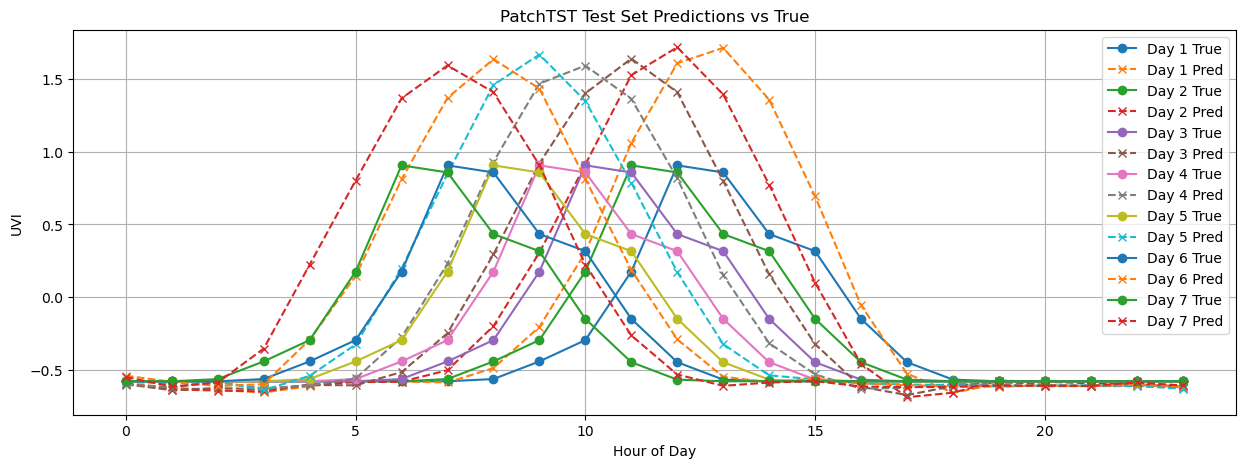

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 假设 y_true, y_pred 已经是 numpy 数组，shape=(num_samples, pred_len)
# 如果是 torch.Tensor，需要先转换：
# y_true = y_true.cpu().numpy()
# y_pred = y_pred.cpu().numpy()

num_days_to_plot = 7  # 画最近7天
pred_len = y_true.shape[1]

# 构建日期索引（这里用测试集开始日期，可替换为你的实际日期）
start_date = pd.to_datetime("2021-10-01 00:00:00")  
date_index = pd.date_range(start=start_date, periods=y_true.shape[0], freq='D')

# 按天画图
plt.figure(figsize=(15, 5))
for i in range(num_days_to_plot):
    plt.plot(range(pred_len), y_true[-num_days_to_plot+i], 'o-', label=f"Day {i+1} True")
    plt.plot(range(pred_len), y_pred[-num_days_to_plot+i], 'x--', label=f"Day {i+1} Pred")

plt.xlabel("Hour of Day")
plt.ylabel("UVI")
plt.title("PatchTST Test Set Predictions vs True")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [10]:
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# 展平
y_true_flat = y_true.reshape(-1)
y_pred_flat = y_pred.reshape(-1)

mae = mean_absolute_error(
    y_true_flat,
    y_pred_flat
)

rmse = np.sqrt(
    mean_squared_error(
        y_true_flat,
        y_pred_flat
    )
)

r2 = r2_score(
    y_true_flat,
    y_pred_flat
)

print("PatchTST Test")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")

PatchTST Test
MAE  = 0.1751
RMSE = 0.3619
R²   = 0.7655


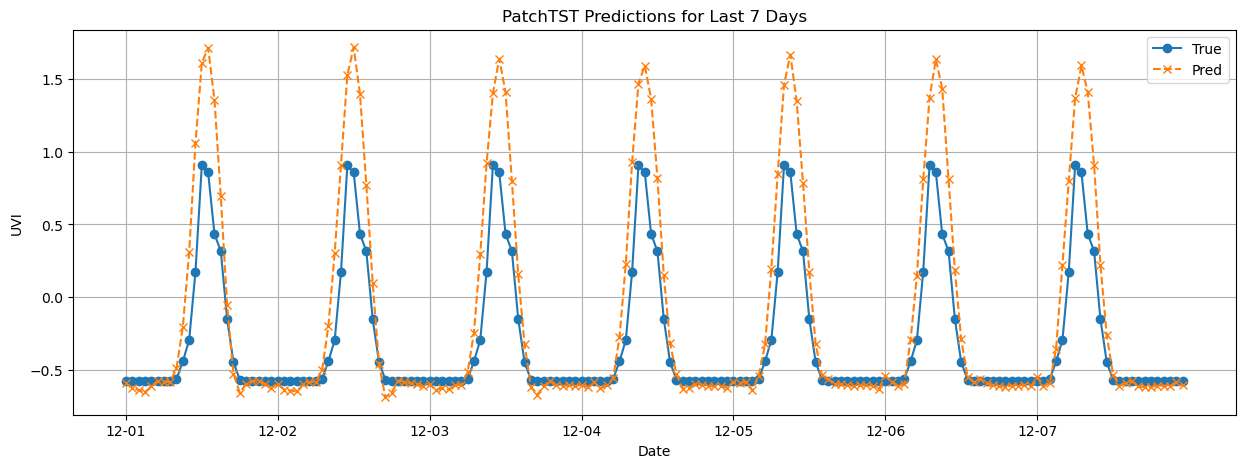

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 假设 y_true, y_pred 已经是 numpy 数组，shape=(num_samples, pred_len)
# 如果是 torch.Tensor，需要先转换：
# y_true = y_true.cpu().numpy()
# y_pred = y_pred.cpu().numpy()

num_days_to_plot = 7
pred_len = y_true.shape[1]

# 取最近 N 天数据
y_true_plot = y_true[-num_days_to_plot:]
y_pred_plot = y_pred[-num_days_to_plot:]

# 展开为连续一维
y_true_flat = y_true_plot.flatten()
y_pred_flat = y_pred_plot.flatten()

# 构建横轴：每个小时一个刻度
hours = np.arange(len(y_true_flat))

# 如果你想用日期标记
start_date = pd.to_datetime("2021-12-01")  # 可改为测试集开始日期
dates = pd.date_range(start=start_date, periods=num_days_to_plot, freq='D')
xticks_pos = np.arange(0, num_days_to_plot*24, 24)
xticks_labels = [d.strftime('%m-%d') for d in dates]

plt.figure(figsize=(15,5))
plt.plot(hours, y_true_flat, 'o-', label="True")
plt.plot(hours, y_pred_flat, 'x--', label="Pred")
plt.xticks(xticks_pos, xticks_labels)
plt.xlabel("Date")
plt.ylabel("UVI")
plt.title(f"PatchTST Predictions for Last {num_days_to_plot} Days")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
print(y_true.min(), y_true.max())
print(y_pred.min(), y_pred.max())

-0.5803558 3.1267917
-0.7487389 3.2018447


In [13]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_true_inv = y_scaler.inverse_transform(
    y_true.reshape(-1,1)
).reshape(y_true.shape)

y_pred_inv = y_scaler.inverse_transform(
    y_pred.reshape(-1,1)
).reshape(y_pred.shape)

y_true_flat = y_true_inv.flatten()
y_pred_flat = y_pred_inv.flatten()

mae = mean_absolute_error(
    y_true_flat,
    y_pred_flat
)

rmse = np.sqrt(
    mean_squared_error(
        y_true_flat,
        y_pred_flat
    )
)

r2 = r2_score(
    y_true_flat,
    y_pred_flat
)

print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")

MAE  = 0.4097
RMSE = 0.8469
R²   = 0.7655


In [15]:
import numpy as np

# 反归一化
y_true_inv = y_scaler.inverse_transform(
    y_true.reshape(-1, 1)
).reshape(y_true.shape)

y_pred_inv = y_scaler.inverse_transform(
    y_pred.reshape(-1, 1)
).reshape(y_pred.shape)

print(y_true_inv.shape)
print(y_pred_inv.shape)

print("真实值范围:")
print(y_true_inv.min(), y_true_inv.max())

print("预测值范围:")
print(y_pred_inv.min(), y_pred_inv.max())

(2022, 24)
(2022, 24)
真实值范围:
3.5782072e-08 8.674167
预测值范围:
-0.39399096 8.849779


In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_true_flat = y_true_inv.flatten()
y_pred_flat = y_pred_inv.flatten()

mae = mean_absolute_error(
    y_true_flat,
    y_pred_flat
)

rmse = np.sqrt(
    mean_squared_error(
        y_true_flat,
        y_pred_flat
    )
)

r2_score(
    y_true.reshape(-1),
    y_pred.reshape(-1)
)

print("PatchTST Test (Original Scale)")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")

PatchTST Test (Original Scale)
MAE  = 0.4097
RMSE = 0.8469
R²   = 0.7655


In [20]:
import numpy as np
import torch

y_true = []

for _, target in test_loader:
    y_true.append(target.numpy())

y_true = np.concatenate(y_true, axis=0)

print(y_true.shape)

(2022, 24)


In [21]:
y_scaler = StandardScaler()

In [23]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# 假设 train_y 是训练集目标列，shape=(num_train, 1)
y_scaler = StandardScaler()
y_scaler.fit(train_y)   # 先拟合训练集真实值

# 然后对测试集做反归一化
y_true_inv = y_scaler.inverse_transform(y_true.reshape(-1,1)).reshape(y_true.shape)
y_pred_inv = y_scaler.inverse_transform(y_pred.reshape(-1,1)).reshape(y_pred.shape)

In [26]:
# 假设你的测试集是 test_df
print("测试集前5条时间：", test_df.index[:5])
print("测试集后5条时间：", test_df.index[-5:])

测试集前5条时间： DatetimeIndex(['2021-10-01 00:00:00', '2021-10-01 01:00:00',
               '2021-10-01 02:00:00', '2021-10-01 03:00:00',
               '2021-10-01 04:00:00'],
              dtype='datetime64[ns]', name='time', freq=None)
测试集后5条时间： DatetimeIndex(['2021-12-29 00:00:00', '2021-12-29 01:00:00',
               '2021-12-29 02:00:00', '2021-12-29 03:00:00',
               '2021-12-29 04:00:00'],
              dtype='datetime64[ns]', name='time', freq=None)


ValueError: x and y must have same first dimension, but have shapes (168,) and (4032,)

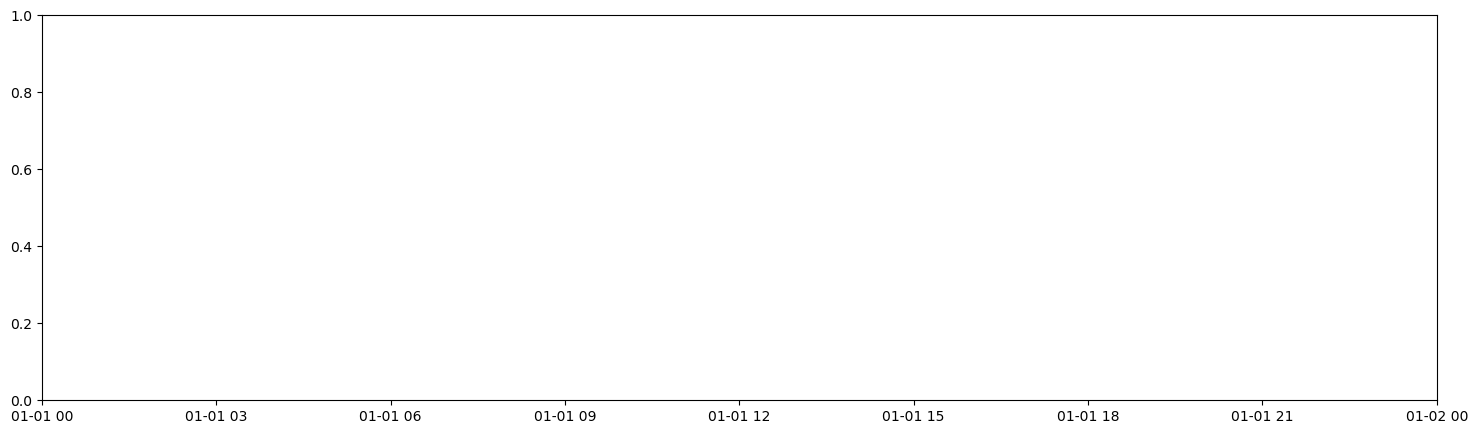

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------------
# 1️⃣ 选择展示的天数
# -------------------------------
days_to_plot = 7  # 展示最近7天
hours_per_day = 24

# 将测试集时间索引转为数组
time_index = test_df.index[-days_to_plot*hours_per_day:]

# -------------------------------
# 2️⃣ 准备绘图数据（反归一化后）
# -------------------------------
true_plot = y_true_inv[-days_to_plot*hours_per_day:].reshape(-1)
pred_plot = y_pred_inv[-days_to_plot*hours_per_day:].reshape(-1)

# -------------------------------
# 3️⃣ 绘制连续小时预测图
# -------------------------------
plt.figure(figsize=(18,5))
plt.plot(time_index, true_plot, label="True", linewidth=2)
plt.plot(time_index, pred_plot, label="Predicted", linewidth=2)
plt.xlabel("Date")
plt.ylabel("UVI")
plt.title(f"Forecast vs True UVI (Last {days_to_plot} Days)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
time_index = []

for i in range(len(preds_inv)):
    start = test_df.index[i + 96]
    rng = pd.date_range(
        start=start,
        periods=24,
        freq='H'
    )
    time_index.extend(rng)

len(time_index)